# Car Price Prediction Model

This notebook demonstrates a complete car price prediction pipeline, from data loading and cleaning to feature engineering and XGBoost model training. All functions are defined inline for clarity.

## 1. Import Required Libraries

Import the necessary libraries for data handling, modeling, and visualization.

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import logging

# Set up logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# Set style for plots
plt.style.use('default')
sns.set_palette("husl")

## 2. Load and Explore Dataset

Load the car dataset and perform initial exploration.

In [10]:
import os
out = os.path.dirname(os.path.dirname(os.getcwd()))
os.chdir(out)

Loaded 2,397 records with 29 columns

First 5 rows:


,make,model,year,price,miles,city,state,body_type,engine,transmission,...,highway_mpg,condition,car_age,miles_per_year,avg_price_model,price_vs_market,data_source,id,title,currency
0,Kia,Sorento,2020,992200,97985,Culiacán,Sinaloa,Sedan,3.0L Diesel,Automatic,...,33.0,Good,6.0,16330.833333,1.326486e+05,859551.382353,autos_mexico,2.692385e+09,Kia Sorento 2.5t Gdi Sxl Dct,MXN
1,Audi,A1,2024,565924,0,Atizapán De Zaragoza,Estado De México,SUV,2.5L 4-Cylinder,Automatic,...,26.0,Good,2.0,0.000000,4.077890e+05,158135.000000,autos_mexico,2.760786e+09,Audi A1 Sportback A1 Sportback 35tfsi 150hp Eg...,MXN
2,Nissan,V,2023,259999,56000,Miguel Hidalgo,Distrito Federal,Sedan,3.0L Diesel,Automatic,...,27.0,Fair,3.0,18666.666667,2.412716e+05,18727.363636,autos_mexico,5.140687e+09,Nissan V-drive Base,MXN
3,Chevrolet,Captiva,2025,494900,0,Hermosillo,Sonora,Hatchback,2.5L 4-Cylinder,Manual,...,27.0,Excellent,1.0,0.000000,3.337983e+05,161101.707317,autos_mexico,4.366919e+09,Chevrolet Captiva 1.5 Premier Black Edition 7p...,MXN
4,Chevrolet,Suburban,2024,1795000,0,Iztacalco,Distrito Federal,Hatchback,2.5L 4-Cylinder,Manual,...,27.0,Excellent,2.0,0.000000,1.510786e+06,284213.769231,autos_mexico,2.738868e+09,Chevrolet Suburban 6.2 High Country 4x4 At,MXN



Data types and missing values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2397 entries, 0 to 2396
Data columns (total 29 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   make             2397 non-null   object 
 1   model            2397 non-null   object 
 2   year             2397 non-null   int64  
 3   price            2397 non-null   int64  
 4   miles            2397 non-null   int64  
 5   city             2397 non-null   object 
 6   state            2397 non-null   object 
 7   body_type        2397 non-null   object 
 8   engine           2397 non-null   object 
 9   transmission     2397 non-null   object 
 10  fuel_type        2397 non-null   object 
 11  drive_train      2397 non-null   object 
 12  cylinders        2397 non-null   float64
 13  doors            2397 non-null   float64
 14  horsepower       2397 non-null   float64
 15  trim             2397 non-null   object 
 16  exterior_color   2397 non-nu

,year,price,miles,cylinders,doors,horsepower,city_mpg,highway_mpg,car_age,miles_per_year,avg_price_model,price_vs_market,id
count,2397.000000,2.397000e+03,2397.000000,2397.000000,2397.000000,2397.000000,2397.000000,2397.000000,2397.000000,2397.000000,2.397000e+03,2.397000e+03,1.449000e+03
mean,2019.720067,3.970213e+05,59736.902795,5.804317,2.943090,273.997708,19.589944,27.502384,5.488945,14223.682634,3.563708e+05,4.065044e+04,3.931107e+09
std,3.935899,5.160340e+05,43238.938966,1.274230,0.803702,58.093310,2.320707,3.697828,3.445677,17782.721535,4.216397e+05,2.819344e+05,1.106780e+09
min,2006.000000,5.000000e+03,0.000000,4.000000,2.000000,150.000000,15.000000,20.000000,1.000000,0.000000,2.004293e+04,-1.881043e+06,2.320508e+09
25%,2017.000000,3.479200e+04,24335.000000,5.000000,2.000000,255.000000,19.000000,26.000000,3.000000,5012.285714,2.943111e+04,-1.164143e+04,2.808485e+09
50%,2020.000000,2.649000e+05,57358.000000,6.000000,3.000000,277.000000,19.000000,27.000000,5.000000,10730.250000,2.529823e+05,1.419700e+03,4.446467e+09
75%,2023.000000,4.950000e+05,90000.000000,6.000000,4.000000,287.000000,20.000000,29.000000,7.000000,17115.000000,4.590579e+05,2.577912e+04,5.058545e+09
max,2025.000000,4.499990e+06,240000.000000,8.000000,4.000000,400.000000,25.000000,35.000000,20.000000,148893.000000,2.689995e+06,3.518046e+06,5.152586e+09


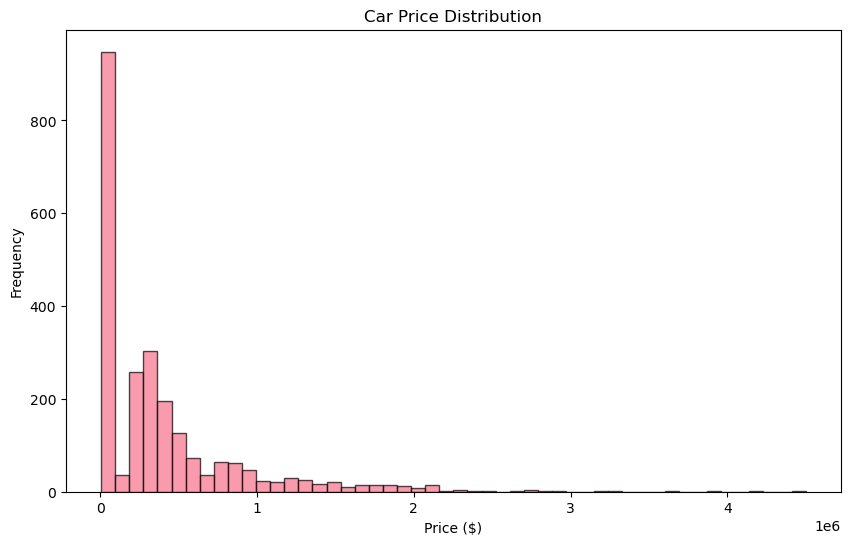

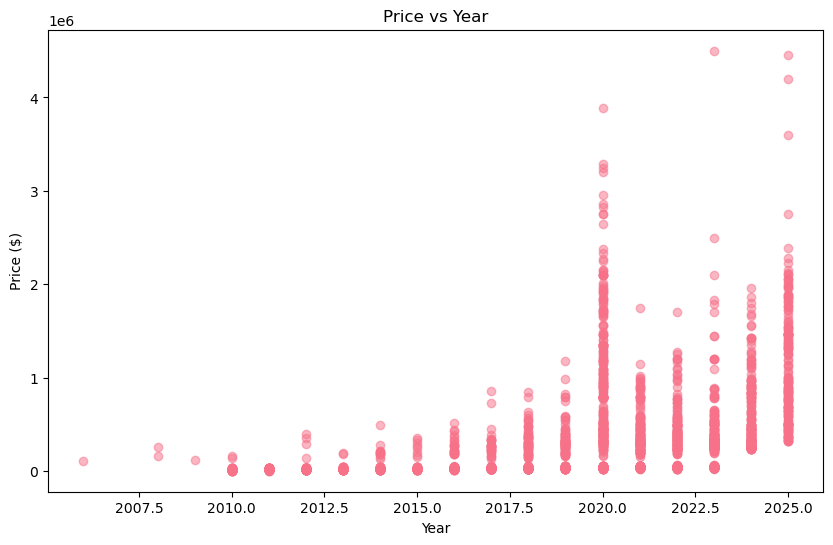

In [11]:
# Load the dataset
data_path = 'data/modeling_data/mexico_cars_complete.csv'
df = pd.read_csv(data_path)

print(f"Loaded {len(df):,} records with {len(df.columns)} columns")
print("\nFirst 5 rows:")
display(df.head())

print("\nData types and missing values:")
print(df.info())

print("\nBasic statistics:")
display(df.describe())

# Visualize price distribution
plt.figure(figsize=(10, 6))
plt.hist(df['price'], bins=50, alpha=0.7, edgecolor='black')
plt.title('Car Price Distribution')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')
plt.show()

# Price vs Year scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(df['year'], df['price'], alpha=0.5)
plt.title('Price vs Year')
plt.xlabel('Year')
plt.ylabel('Price ($)')
plt.show()

## 3. Preprocess Data

Define and apply data preprocessing functions to handle missing values and prepare the data.

In [12]:
def fill_missing_from_make_model(df):
    """Fill missing values by grouping on make and model"""
    fill_cols = ['engine', 'transmission', 'fuel_type', 'body_type', 
                 'drive_train', 'cylinders', 'doors', 'horsepower', 
                 'trim', 'exterior_color', 'condition']
    numeric_cols = ['horsepower', 'cylinders', 'doors', 'city_mpg', 'highway_mpg']
    
    print("Filling missing values from make/model groups...")
    grouped = df.groupby(['make', 'model'], group_keys=False)
    
    def fill_from_group(group):
        for col in fill_cols:
            if group[col].isnull().any():
                if col in numeric_cols:
                    fill_value = group[col].mean()
                else:
                    mode_val = group[col].mode()
                    fill_value = mode_val[0] if len(mode_val) > 0 else None
                
                if pd.notna(fill_value):
                    group[col] = group[col].fillna(fill_value)
        return group
    
    df = grouped.apply(fill_from_group)
    print("✅ Filled from make/model groups")
    return df

def fill_missing_from_make(df):
    """Fill remaining missing values at make (brand) level"""
    fill_cols = ['engine', 'transmission', 'fuel_type', 'body_type', 
                 'drive_train', 'cylinders', 'doors', 'horsepower', 'condition']
    numeric_cols = ['horsepower', 'cylinders', 'doors', 'city_mpg', 'highway_mpg']
    
    print("Filling remaining missing values from make level...")
    grouped_make = df.groupby('make', group_keys=False)
    
    def fill_from_group(group):
        for col in fill_cols:
            if group[col].isnull().any():
                if col in numeric_cols:
                    fill_value = group[col].mean()
                else:
                    mode_val = group[col].mode()
                    fill_value = mode_val[0] if len(mode_val) > 0 else None
                
                if pd.notna(fill_value):
                    group[col] = group[col].fillna(fill_value)
        return group
    
    df = grouped_make.apply(fill_from_group)
    print("✅ Filled from make groups")
    return df

def fill_missing_at_global(df):
    """Fill remaining missing values using global statistics"""
    fill_cols = ['body_type', 'engine', 'transmission', 'fuel_type', 
                 'drive_train', 'trim', 'condition']
    numeric_cols = ['city_mpg', 'highway_mpg']
    
    print("Filling remaining missing values at global level...")
    
    for col in fill_cols:
        if col in df.columns and df[col].isnull().any():
            mode_val = df[col].mode()
            if len(mode_val) > 0:
                df[col] = df[col].fillna(mode_val[0])
                print(f"  Filled {col} with mode: {mode_val[0]}")
    
    for col in numeric_cols:
        if col in df.columns and df[col].isnull().any():
            mean_val = df[col].mean()
            df[col] = df[col].fillna(mean_val)
            print(f"  Filled {col} with mean: {mean_val:.2f}")
    
    return df

def calculate_derived_columns(df, current_year=2026):
    """Calculate derived columns (car_age, miles_per_year, market metrics)"""
    print("Calculating derived columns...")
    
    if 'car_age' not in df.columns or df['car_age'].isnull().any():
        df['car_age'] = df['car_age'].fillna(current_year - df['year'])
        print(f"  Calculated car_age = {current_year} - year")
    
    if 'miles_per_year' not in df.columns or df['miles_per_year'].isnull().any():
        df['miles_per_year'] = df['miles_per_year'].fillna(
            df.apply(lambda row: row['miles'] / row['car_age'] if row['car_age'] > 0 else 0, axis=1)
        )
        print("  Calculated miles_per_year = miles / car_age")
    
    if 'avg_price_model' not in df.columns or df['avg_price_model'].isnull().any():
        avg_price_per_model = df.groupby(['make', 'model'])['price'].transform('mean')
        df['avg_price_model'] = df['avg_price_model'].fillna(avg_price_per_model)
        print("  Calculated avg_price_model = mean(price) by make/model")
    
    if 'price_vs_market' not in df.columns or df['price_vs_market'].isnull().any():
        df['price_vs_market'] = df['price_vs_market'].fillna(
            df['price'] - df['avg_price_model']
        )
        print("  Calculated price_vs_market = price - avg_price_model")
    
    return df

def clean_dataset(df):
    """Comprehensive dataset cleaning pipeline"""
    print("Starting comprehensive data cleaning...")
    
    df = fill_missing_from_make_model(df)
    df = fill_missing_from_make(df)
    df = fill_missing_at_global(df)
    df = calculate_derived_columns(df)
    
    initial_len = len(df)
    df = df.drop_duplicates()
    if len(df) < initial_len:
        print(f"Removed {initial_len - len(df)} duplicate rows")
    
    print(f"✅ Data cleaning complete! Final size: {len(df)} rows")
    return df

# Apply data cleaning
df_clean = clean_dataset(df)
print(f"\nOriginal dataset: {len(df)} rows")
print(f"Cleaned dataset: {len(df_clean)} rows")

Starting comprehensive data cleaning...
Filling missing values from make/model groups...


/var/folders/kf/72rqk1d90ps_2x5p1fv5vg2m0000gp/T/ipykernel_43918/2995034669.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = grouped.apply(fill_from_group)
/var/folders/kf/72rqk1d90ps_2x5p1fv5vg2m0000gp/T/ipykernel_43918/2995034669.py:50: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = grouped_make.apply(fill_from_group)


✅ Filled from make/model groups
Filling remaining missing values from make level...
✅ Filled from make groups
Filling remaining missing values at global level...
Calculating derived columns...
✅ Data cleaning complete! Final size: 2397 rows

Original dataset: 2397 rows
Cleaned dataset: 2397 rows


## 4. Define Feature Engineering Functions

Define functions to create new features from the cleaned data.

In [13]:
def create_make_model_mileage_label(df):
    """Create a composite label: make_model_mileage"""
    print("Creating make_model_mileage label...")
    
    df['mileage_range'] = pd.cut(
        df['miles'],
        bins=[0, 20000, 50000, 100000, 150000, 250000],
        labels=['0-20k', '20-50k', '50-100k', '100-150k', '150k+']
    )
    
    df['make_model_mileage'] = (
        df['make'] + '_' + 
        df['model'].str.replace(' ', '_') + '_' + 
        df['mileage_range'].astype(str)
    )
    
    print(f"Created {df['make_model_mileage'].nunique()} unique make_model_mileage groups")
    return df

def create_brand_statistics(df):
    """Create aggregated statistics by brand (make)"""
    print("Calculating brand statistics...")
    
    df['brand_avg_price'] = df['make'].map(df.groupby('make')['price'].mean())
    df['brand_median_price'] = df['make'].map(df.groupby('make')['price'].median())
    df['brand_price_std'] = df['make'].map(df.groupby('make')['price'].std())
    df['brand_car_count'] = df['make'].map(df.groupby('make').size())
    
    print("Created brand statistics features")
    return df

def create_year_statistics(df):
    """Create aggregated statistics by year"""
    print("Calculating year statistics...")
    
    df['year_avg_price'] = df['year'].map(df.groupby('year')['price'].mean())
    df['year_median_price'] = df['year'].map(df.groupby('year')['price'].median())
    
    print("Created year statistics features")
    return df

def create_make_model_statistics(df):
    """Create aggregated statistics by make and model"""
    print("Calculating make/model statistics...")
    
    df['model_avg_price'] = df.groupby(['make', 'model'])['price'].transform('mean')
    df['model_median_price'] = df.groupby(['make', 'model'])['price'].transform('median')
    df['model_price_std'] = df.groupby(['make', 'model'])['price'].transform('std')
    
    print("Created make/model statistics features")
    return df

def create_mileage_range_statistics(df):
    """Create statistics by mileage ranges"""
    print("Calculating mileage range statistics...")
    
    df['mileage_range_avg_price'] = df['mileage_range'].map(
        df.groupby('mileage_range')['price'].mean()
    )
    
    print("Created mileage range statistics features")
    return df

def create_body_type_features(df):
    """Create features for different body types (SUVs, Luxury, etc.)"""
    print("Creating body type classification features...")
    
    suv_types = ['SUV', 'Truck']
    luxury_brands = ['BMW', 'Mercedes-Benz', 'Audi', 'Porsche', 'Jaguar', 'Cadillac', 'Lexus']
    sports_types = ['Sports', 'Coupe', 'Convertible']
    
    df['is_suv'] = df['body_type'].isin(suv_types).astype(int)
    df['is_luxury_brand'] = df['make'].isin(luxury_brands).astype(int)
    df['is_sports'] = df['body_type'].isin(sports_types).astype(int)
    df['is_sedan'] = (df['body_type'] == 'Sedan').astype(int)
    df['is_hatchback'] = (df['body_type'] == 'Hatchback').astype(int)
    
    df['suv_avg_price'] = df['is_suv'].map({
        1: df[df['is_suv'] == 1]['price'].mean(),
        0: df[df['is_suv'] == 0]['price'].mean()
    })
    
    df['luxury_brand_avg_price'] = df['is_luxury_brand'].map({
        1: df[df['is_luxury_brand'] == 1]['price'].mean(),
        0: df[df['is_luxury_brand'] == 0]['price'].mean()
    })
    
    print("Created body type classification features")
    return df

def create_price_ratio_features(df):
    """Create ratio-based features for price analysis"""
    print("Creating price ratio features...")
    
    df['price_per_mile'] = df['price'] / (df['miles'] + 1)
    df['price_per_age'] = df['price'] / (df['car_age'] + 0.1)
    
    print("Created price ratio features")
    return df

def encode_categorical_features(df):
    """Encode categorical features using label encoding"""
    print("Encoding categorical features...")
    
    categorical_cols = ['make', 'model', 'body_type', 'transmission', 'fuel_type', 
                       'drive_train', 'condition', 'exterior_color', 'trim', 
                       'make_model_mileage', 'mileage_range']
    
    encoders = {}
    for col in categorical_cols:
        if col in df.columns:
            le = LabelEncoder()
            df[f'{col}_encoded'] = le.fit_transform(df[col].astype(str))
            encoders[col] = le
            print(f"  Encoded {col} with {len(le.classes_)} unique values")
    
    print("✅ Categorical encoding complete")
    return df, encoders

def create_all_features(df):
    """Apply all feature engineering steps"""
    print("Starting comprehensive feature engineering...")
    
    df = create_make_model_mileage_label(df)
    df = create_brand_statistics(df)
    df = create_year_statistics(df)
    df = create_make_model_statistics(df)
    df = create_mileage_range_statistics(df)
    df = create_body_type_features(df)
    df = create_price_ratio_features(df)
    df, encoders = encode_categorical_features(df)
    
    print(f"✅ Feature engineering complete! Final shape: {df.shape}")
    return df, encoders

# Apply feature engineering
df_engineered, encoders = create_all_features(df_clean)
print(f"\nOriginal features: {len(df_clean.columns)}")
print(f"Engineered features: {len(df_engineered.columns)}")

Starting comprehensive feature engineering...
Creating make_model_mileage label...
Created 528 unique make_model_mileage groups
Calculating brand statistics...
Created brand statistics features
Calculating year statistics...
Created year statistics features
Calculating make/model statistics...
Created make/model statistics features
Calculating mileage range statistics...


/var/folders/kf/72rqk1d90ps_2x5p1fv5vg2m0000gp/T/ipykernel_43918/3559108185.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('mileage_range')['price'].mean()


Created mileage range statistics features
Creating body type classification features...
Created body type classification features
Creating price ratio features...
Created price ratio features
Encoding categorical features...
  Encoded make with 23 unique values
  Encoded model with 201 unique values
  Encoded body_type with 4 unique values
  Encoded transmission with 3 unique values
  Encoded fuel_type with 3 unique values
  Encoded drive_train with 3 unique values
  Encoded condition with 4 unique values
  Encoded exterior_color with 7 unique values
  Encoded trim with 5 unique values
  Encoded make_model_mileage with 528 unique values
  Encoded mileage_range with 6 unique values
✅ Categorical encoding complete
✅ Feature engineering complete! Final shape: (2397, 61)

Original features: 61
Engineered features: 61


## 5. Define Model Training Function

Define a function that trains an XGBoost regression model on the engineered features.

In [14]:
def prepare_features(df, target_col='price'):
    """Prepare features for modeling"""
    print("Preparing features for modeling...")
    
    # Define feature columns (exclude target and non-numeric)
    exclude_cols = [target_col, 'title', 'url']  # Add any text columns to exclude
    feature_cols = []
    
    for col in df.columns:
        if col not in exclude_cols:
            # Include numeric columns and encoded categorical columns
            if df[col].dtype in ['int64', 'float64', 'int32', 'float32'] or '_encoded' in col:
                feature_cols.append(col)
    
    X = df[feature_cols]
    y = df[target_col]
    
    print(f"Selected {len(feature_cols)} features for modeling")
    print(f"Target variable: {target_col}")
    return X, y, feature_cols

def train_test_split_data(X, y, test_size=0.2, random_state=42):
    """Split data into train and test sets"""
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )
    
    print(f"Train set: {len(X_train)} samples")
    print(f"Test set: {len(X_test)} samples")
    return X_train, X_test, y_train, y_test

def train_xgb_model(X_train, y_train, xgb_params=None):
    """Train XGBoost model"""
    if xgb_params is None:
        xgb_params = {
            'max_depth': 6,
            'learning_rate': 0.1,
            'n_estimators': 200,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'min_child_weight': 1,
            'gamma': 0,
            'reg_alpha': 0,
            'reg_lambda': 1
        }
    
    print("Training XGBoost model...")
    model = xgb.XGBRegressor(**xgb_params, random_state=42)
    model.fit(X_train, y_train)
    
    print("✅ Model training complete")
    return model

def evaluate_model(model, X_test, y_test):
    """Evaluate model performance"""
    print("Evaluating model performance...")
    
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    
    metrics = {
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
        'MAPE': mape,
        'y_pred': y_pred
    }
    
    print(f"  MAE (Mean Absolute Error):     ${mae:,.2f}")
    print(f"  RMSE (Root Mean Squared Error): ${rmse:,.2f}")
    print(f"  R² Score:                      {r2:.4f}")
    print(f"  MAPE (Mean Absolute % Error):  {mape:.2f}%")
    
    return metrics

def get_feature_importance(model, feature_cols, top_n=15):
    """Get feature importance ranking"""
    importance = pd.DataFrame({
        'feature': feature_cols,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print(f"\nTop {top_n} Most Important Features:")
    for i, (_, row) in enumerate(importance.head(top_n).iterrows(), 1):
        print(f"  {i}. {row['feature']:<30} {row['importance']:.4f}")
    
    return importance

# Prepare features and split data
X, y, feature_cols = prepare_features(df_engineered)
X_train, X_test, y_train, y_test = train_test_split_data(X, y)

# Train model
xgb_params = {
    'max_depth': 6,
    'learning_rate': 0.1,
    'n_estimators': 200,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 1,
    'gamma': 0,
    'reg_alpha': 0,
    'reg_lambda': 1
}

model = train_xgb_model(X_train, y_train, xgb_params)

Preparing features for modeling...
Selected 41 features for modeling
Target variable: price
Train set: 1917 samples
Test set: 480 samples
Training XGBoost model...
✅ Model training complete


## 6. Define Prediction Function

Define a function to make predictions on new car data using the trained model.

In [15]:
def make_predictions(model, new_data, feature_cols, encoders):
    """Make predictions on new car data"""
    print("Making predictions on new data...")
    
    # Apply the same preprocessing and feature engineering
    new_data_processed = clean_dataset(new_data.copy())
    new_data_processed, _ = create_all_features(new_data_processed)
    
    # Ensure all required features are present
    missing_features = set(feature_cols) - set(new_data_processed.columns)
    if missing_features:
        print(f"Warning: Missing features: {missing_features}")
        # Add missing features with default values
        for feat in missing_features:
            new_data_processed[feat] = 0
    
    # Select only the features used in training
    X_new = new_data_processed[feature_cols]
    
    # Make predictions
    predictions = model.predict(X_new)
    
    print(f"✅ Generated {len(predictions)} predictions")
    return predictions

# Evaluate the model
metrics = evaluate_model(model, X_test, y_test)

# Get feature importance
importance = get_feature_importance(model, feature_cols)

# Example prediction on test data
sample_predictions = make_predictions(model, df_engineered.sample(5), feature_cols, encoders)
print(f"\nSample predictions: {sample_predictions}")

Evaluating model performance...
  MAE (Mean Absolute Error):     $16,115.47
  RMSE (Root Mean Squared Error): $49,096.48
  R² Score:                      0.9893
  MAPE (Mean Absolute % Error):  4.54%

Top 15 Most Important Features:
  1. price_per_age                  0.3847
  2. avg_price_model                0.1838
  3. price_per_mile                 0.1701
  4. id                             0.0474
  5. price_vs_market                0.0441
  6. model_avg_price                0.0403
  7. model_price_std                0.0345
  8. model_median_price             0.0325
  9. city_mpg                       0.0079
  10. year_avg_price                 0.0073
  11. year                           0.0063
  12. trim_encoded                   0.0062
  13. fuel_type_encoded              0.0049
  14. miles                          0.0037
  15. drive_train_encoded            0.0030
Making predictions on new data...
Starting comprehensive data cleaning...
Filling missing values from make/model gro

/var/folders/kf/72rqk1d90ps_2x5p1fv5vg2m0000gp/T/ipykernel_43918/2995034669.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = grouped.apply(fill_from_group)
/var/folders/kf/72rqk1d90ps_2x5p1fv5vg2m0000gp/T/ipykernel_43918/2995034669.py:50: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = grouped_make.apply(fill_from_group)
/var/folders/kf/72rqk1d90ps_2x5p1fv5vg2m0000gp/T/ipykernel_43918/3559108185

✅ Filled from make/model groups
Filling remaining missing values from make level...
✅ Filled from make groups
Filling remaining missing values at global level...
Calculating derived columns...
✅ Data cleaning complete! Final size: 5 rows
Starting comprehensive feature engineering...
Creating make_model_mileage label...
Created 5 unique make_model_mileage groups
Calculating brand statistics...
Created brand statistics features
Calculating year statistics...
Created year statistics features
Calculating make/model statistics...
Created make/model statistics features
Calculating mileage range statistics...
Created mileage range statistics features
Creating body type classification features...
Created body type classification features
Creating price ratio features...
Created price ratio features
Encoding categorical features...
  Encoded make with 4 unique values
  Encoded model with 5 unique values
  Encoded body_type with 4 unique values
  Encoded transmission with 3 unique values
  Encod

## 7. Demonstrate Model Usage

Run the complete pipeline and show results, including visualizations and analysis.

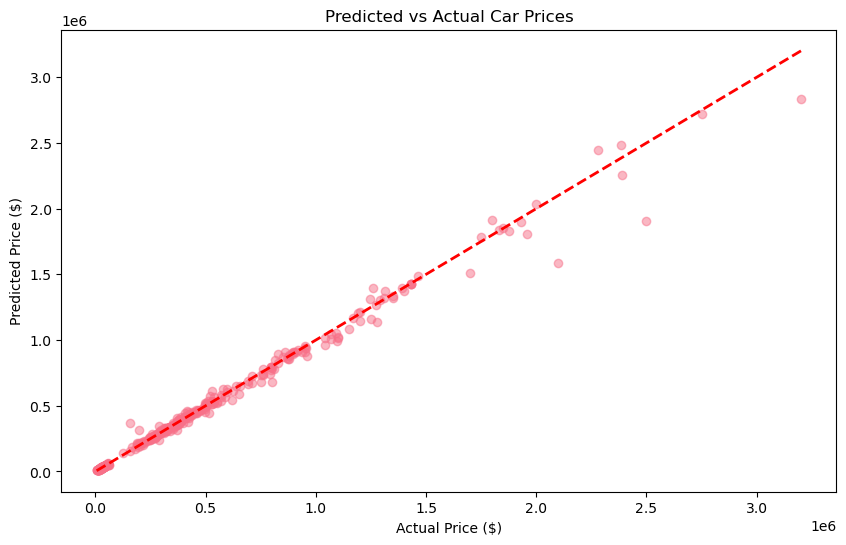

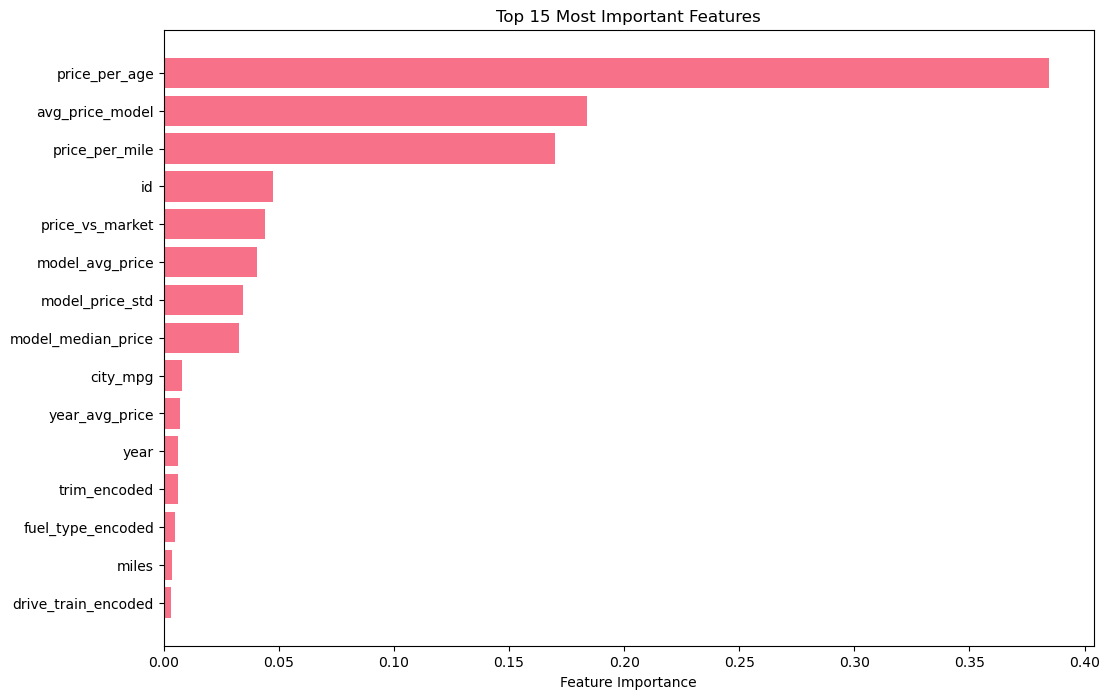

✅ Model saved to models/car_price_xgb_model.pkl
✅ Results saved to results/ directory
R² Score: 0.9893
MAE: $16,115.47
MAPE: 4.54%


In [16]:
# Visualize predictions vs actual
plt.figure(figsize=(10, 6))
plt.scatter(y_test, metrics['y_pred'], alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('Predicted vs Actual Car Prices')
plt.show()

# Feature importance plot
plt.figure(figsize=(12, 8))
top_features = importance.head(15)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Feature Importance')
plt.title('Top 15 Most Important Features')
plt.gca().invert_yaxis()
plt.show()

# Save model
import pickle
with open('models/car_price_xgb_model.pkl', 'wb') as f:
    pickle.dump(model, f)
print("✅ Model saved to models/car_price_xgb_model.pkl")

# Save results
importance.to_csv('results/feature_importance.csv', index=False)
pd.DataFrame({
    'actual_price': y_test.values,
    'predicted_price': metrics['y_pred'],
    'error': y_test.values - metrics['y_pred'],
    'error_pct': ((y_test.values - metrics['y_pred']) / y_test.values * 100)
}).to_csv('results/model_predictions.csv', index=False)

metrics_summary = {
    'MAE': metrics['MAE'],
    'RMSE': metrics['RMSE'],
    'R2_Score': metrics['R2'],
    'MAPE': metrics['MAPE'],
    'Train_Size': len(X_train),
    'Test_Size': len(X_test),
    'Total_Records': len(df),
    'Total_Features': len(feature_cols)
}
pd.DataFrame([metrics_summary]).to_csv('results/model_metrics.csv', index=False)

print("✅ Results saved to results/ directory")
print(f"R² Score: {metrics['R2']:.4f}")
print(f"MAE: ${metrics['MAE']:,.2f}")
print(f"MAPE: {metrics['MAPE']:.2f}%")